In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import time
import os

📝 Создаём синтетические изображения для панорамы...
✅ Создано 3 изображений для панорамы


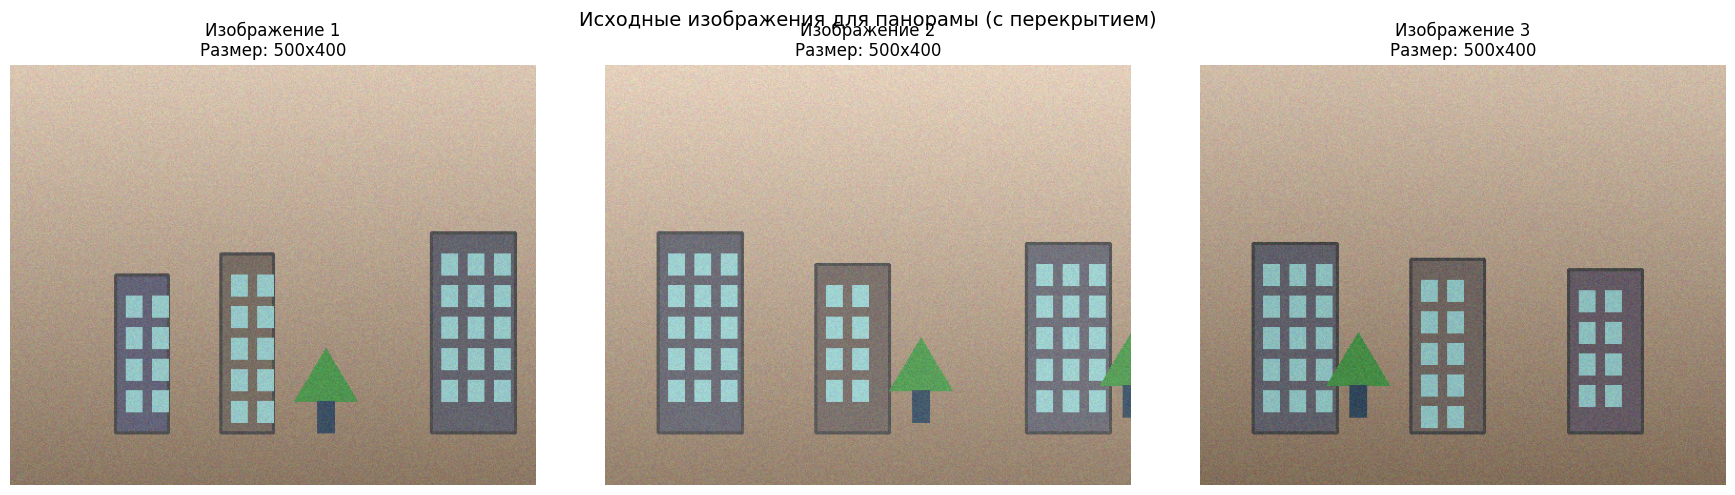

In [12]:
# ===============================
# Загрузка или создание тестовых изображений
# ===============================

def create_panorama_test_images():
    """Создаёт набор перекрывающихся изображений для сшивки"""

    print("📝 Создаём синтетические изображения для панорамы...")

    # Базовое широкое изображение
    base_width = 1200
    base_height = 400
    base = np.ones((base_height, base_width, 3), dtype=np.uint8) * 200

    # Добавляем фон (градиент неба)
    for y in range(base_height):
        intensity = int(180 - y * 0.2)
        base[y, :] = [intensity, intensity + 20, intensity + 40]

    # Добавляем объекты в разных позициях
    # Здания
    buildings = [
        (100, 200, 150, 350, (120, 100, 100)),
        (200, 180, 250, 350, (100, 110, 120)),
        (400, 160, 480, 350, (110, 100, 100)),
        (550, 190, 620, 350, (100, 105, 115)),
        (750, 170, 830, 350, (115, 105, 105)),
        (900, 185, 970, 350, (105, 110, 120)),
        (1050, 195, 1120, 350, (110, 100, 110))
    ]

    for x1, y1, x2, y2, color in buildings:
        cv2.rectangle(base, (x1, y1), (x2, y2), color, -1)
        cv2.rectangle(base, (x1, y1), (x2, y2), (80, 80, 80), 2)

        # Окна
        for wy in range(y1 + 20, y2 - 20, 30):
            for wx in range(x1 + 10, x2 - 10, 25):
                cv2.rectangle(base, (wx, wy), (wx + 15, wy + 20), (200, 200, 150), -1)

    # Деревья (зелёные треугольники)
    trees = [(300, 320), (650, 310), (850, 305)]
    for tx, ty in trees:
        tree = np.array([[tx, ty - 50], [tx - 30, ty], [tx + 30, ty]], np.int32)
        cv2.fillPoly(base, [tree], (80, 150, 80))
        cv2.rectangle(base, (tx - 8, ty), (tx + 8, ty + 30), (100, 80, 60), -1)

    # Добавляем текстуру (шум)
    noise = np.random.randint(-15, 15, base.shape, dtype=np.int16)
    base = np.clip(base.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Создаём 3 перекрывающихся изображения
    images = []

    # Левое изображение
    img1 = base[:, 0:500].copy()
    images.append(img1)

    # Центральное изображение (перекрытие ~30%)
    img2 = base[:, 350:850].copy()
    # Добавляем небольшое изменение яркости
    img2 = np.clip(img2.astype(np.int16) + 10, 0, 255).astype(np.uint8)
    images.append(img2)

    # Правое изображение
    img3 = base[:, 700:1200].copy()
    # Добавляем небольшое изменение яркости
    img3 = np.clip(img3.astype(np.int16) - 10, 0, 255).astype(np.uint8)
    images.append(img3)

    print(f"✅ Создано {len(images)} изображений для панорамы")
    return images

# Загружаем или создаём изображения
images = create_panorama_test_images()

# Визуализируем исходные изображения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, img in enumerate(images):
    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'Изображение {i+1}\nРазмер: {img.shape[1]}x{img.shape[0]}')
    axes[i].axis('off')

plt.suptitle('Исходные изображения для панорамы (с перекрытием)', fontsize=14)
plt.tight_layout()
plt.show()



1. СОЗДАНИЕ 360° ПАНОРАМЫ
Создание синтетических изображений для 360° панорамы...
Создано 8 изображений для 360° панорамы


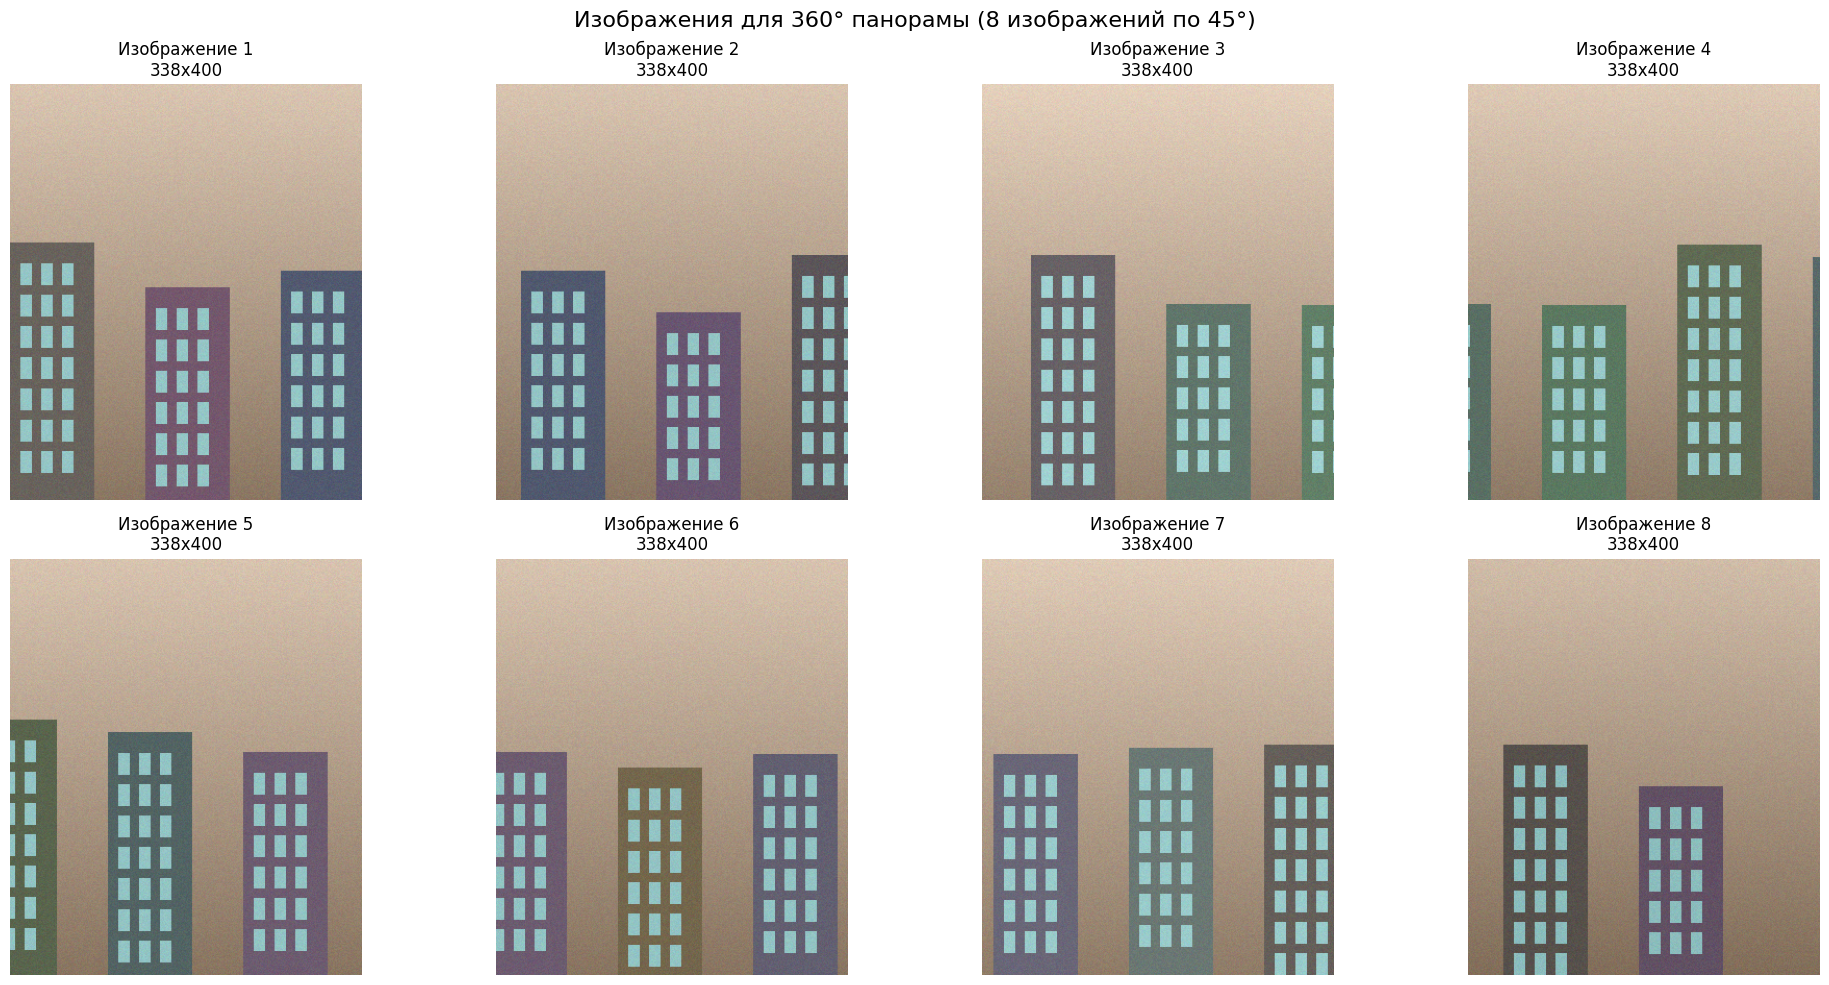

Сшивание 360° панорамы...
Используем SIFT детектор
Изображение 1: 449 ключевых точек
Изображение 2: 392 ключевых точек
Изображение 3: 330 ключевых точек
Изображение 4: 304 ключевых точек
Изображение 5: 378 ключевых точек
Изображение 6: 440 ключевых точек
Изображение 7: 533 ключевых точек
Изображение 8: 310 ключевых точек
Соответствий между изображениями 1 и 2: 130
Соответствий между изображениями 2 и 3: 97
Соответствий между изображениями 3 и 4: 114
Соответствий между изображениями 4 и 5: 86
Соответствий между изображениями 5 и 6: 100
Соответствий между изображениями 6 и 7: 114
Соответствий между изображениями 7 и 8: 113
Размер 360° панорамы: 752x452


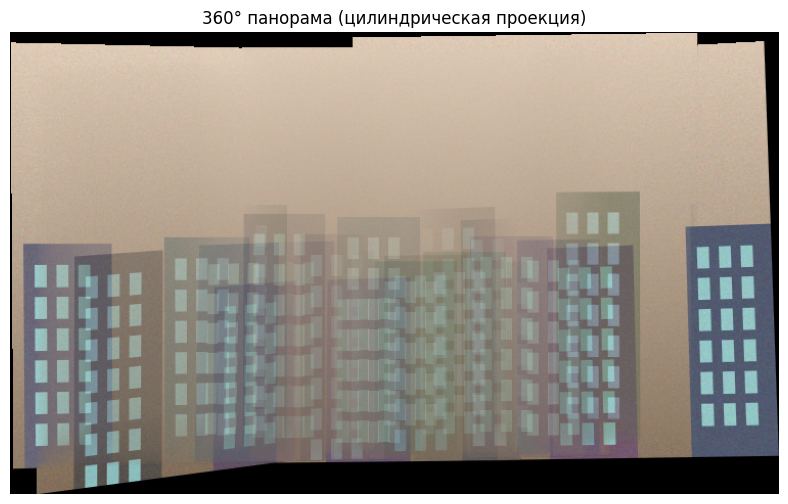


Проверка непрерывности 360° панорамы:


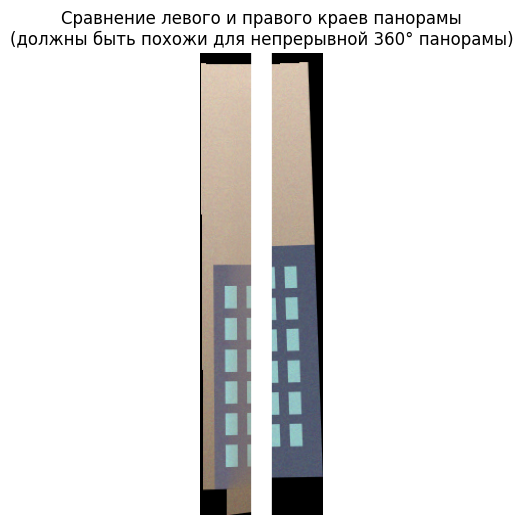

In [23]:
# ============================================
# 1. СОЗДАНИЕ 360° ПАНОРАМЫ
# ============================================

def create_360_panorama_images():
    print("Создание синтетических изображений для 360° панорамы...")

    # Базовое цилиндрическое изображение (развертка 360°)
    base_width = 2000  # Широкое изображение для 360°
    base_height = 400
    base = np.ones((base_height, base_width, 3), dtype=np.uint8) * 200

    # Создаем градиентный фон (имитация неба)
    for y in range(base_height):
        intensity = int(180 - y * 0.2)
        base[y, :] = [intensity, intensity + 20, intensity + 40]

    # Добавляем повторяющиеся объекты для создания эффекта непрерывности
    # Это имитирует объекты, которые видны при вращении на 360°
    objects = []

    # Создаем серию зданий с разными интервалами
    for i in range(15):
        x = i * 130
        height = np.random.randint(150, 250)
        color = (np.random.randint(80, 120),
                np.random.randint(80, 120),
                np.random.randint(80, 120))
        objects.append((x, base_height - height, x + 80, base_height, color))

    # Добавляем объекты на базовое изображение
    for x1, y1, x2, y2, color in objects:
        cv2.rectangle(base, (x1, y1), (x2, y2), color, -1)

        # Добавляем окна
        for wy in range(y1 + 20, y2 - 20, 30):
            for wx in range(x1 + 10, x2 - 10, 20):
                cv2.rectangle(base, (wx, wy), (wx + 10, wy + 20), (200, 200, 150), -1)

    # Создаем 8 изображений для 360° панорамы (каждое 45°)
    images_360 = []
    num_images = 8
    overlap = 0.3  # 30% перекрытия

    # Вычисляем ширину каждого сегмента с учетом перекрытия
    segment_width = int(base_width / (num_images * (1 - overlap) + overlap))

    for i in range(num_images):
        # Вычисляем начальную и конечную позиции для каждого сегмента
        start_x = int(i * segment_width * (1 - overlap))
        end_x = start_x + segment_width

        # Извлекаем сегмент
        segment = base[:, start_x:end_x].copy()

        # Добавляем небольшое изменение яркости для реалистичности
        brightness = np.random.randint(-15, 15)
        segment = np.clip(segment.astype(np.int16) + brightness, 0, 255).astype(np.uint8)

        # Добавляем небольшой шум
        noise = np.random.randint(-10, 10, segment.shape, dtype=np.int16)
        segment = np.clip(segment.astype(np.int16) + noise, 0, 255).astype(np.uint8)

        images_360.append(segment)

    print(f"Создано {len(images_360)} изображений для 360° панорамы")
    return images_360, base

def cylindrical_projection(image, focal_length):

    height, width = image.shape[:2]

    # Создаем пустое изображение для результата
    projected = np.zeros_like(image)

    # Центр изображения
    center_x = width // 2
    center_y = height // 2

    for y in range(height):
        for x in range(width):
            # Вычисляем углы
            theta = np.arctan((x - center_x) / focal_length)
            h = (y - center_y) / np.sqrt((x - center_x)**2 + focal_length**2)

            # Новые координаты
            x_proj = int(focal_length * theta + center_x)
            y_proj = int(focal_length * h + center_y)

            # Проверяем границы
            if 0 <= x_proj < width and 0 <= y_proj < height:
                projected[y_proj, x_proj] = image[y, x]

    return projected

def stitch_360_panorama(images):
    """
    Сшивает изображения в 360° панораму.
    """
    print("Сшивание 360° панорамы...")

    # Инициализируем детектор
    try:
        detector = cv2.SIFT_create()
        print("Используем SIFT детектор")
    except:
        detector = cv2.ORB_create(nfeatures=2000)
        print("Используем ORB детектор")

    # Детектируем ключевые точки и дескрипторы
    keypoints_list = []
    descriptors_list = []

    for i, img in enumerate(images):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        kp, des = detector.detectAndCompute(gray, None)
        keypoints_list.append(kp)
        descriptors_list.append(des)
        print(f"Изображение {i+1}: {len(kp)} ключевых точек")

    # Сопоставляем изображения
    homographies = []

    for i in range(len(images) - 1):
        # Сопоставляем дескрипторы
        if descriptors_list[i].dtype == np.float32:
            matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
        else:
            matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

        matches = matcher.knnMatch(descriptors_list[i], descriptors_list[i+1], k=2)

        # Применяем тест отношения Лоу
        good_matches = []
        for m_n in matches:
            if len(m_n) == 2:
                m, n = m_n
                if m.distance < 0.75 * n.distance:
                    good_matches.append(m)

        print(f"Соответствий между изображениями {i+1} и {i+2}: {len(good_matches)}")

        # Вычисляем гомографию
        if len(good_matches) >= 4:
            src_pts = np.float32([keypoints_list[i][m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst_pts = np.float32([keypoints_list[i+1][m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

            H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
            homographies.append(H)
        else:
            homographies.append(None)

    # Сшиваем все изображения
    base_idx = len(images) // 2

    # Вычисляем составные гомографии
    cumulative_H = [None] * len(images)
    cumulative_H[base_idx] = np.eye(3)

    # Для изображений справа от базового
    for i in range(base_idx + 1, len(images)):
        if cumulative_H[i-1] is not None and homographies[i-1] is not None:
            cumulative_H[i] = cumulative_H[i-1] @ homographies[i-1]

    # Для изображений слева от базового
    for i in range(base_idx - 1, -1, -1):
        if cumulative_H[i+1] is not None and homographies[i] is not None:
            H_inv = np.linalg.inv(homographies[i])
            cumulative_H[i] = cumulative_H[i+1] @ H_inv

    # Находим границы панорамы
    corners_all = []

    for i, img in enumerate(images):
        if cumulative_H[i] is None:
            continue

        h, w = img.shape[:2]
        corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
        corners_transformed = cv2.perspectiveTransform(corners, cumulative_H[i])
        corners_all.append(corners_transformed)

    corners_all = np.concatenate(corners_all, axis=0)
    [x_min, y_min] = np.int32(corners_all.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(corners_all.max(axis=0).ravel() + 0.5)

    translation_dist = [-x_min, -y_min]
    H_translation = np.array([[1, 0, translation_dist[0]],
                              [0, 1, translation_dist[1]],
                              [0, 0, 1]])

    output_width = x_max - x_min
    output_height = y_max - y_min

    # Создаем панораму с alpha blending
    panorama = np.zeros((output_height, output_width, 3), dtype=np.float32)
    weights = np.zeros((output_height, output_width), dtype=np.float32)

    for i, img in enumerate(images):
        if cumulative_H[i] is None:
            continue

        H_adjusted = H_translation @ cumulative_H[i]
        img_warped = cv2.warpPerspective(img, H_adjusted, (output_width, output_height))

        # Создаем маску весов (расстояние до границы)
        h, w = img.shape[:2]
        mask = np.ones((h, w), dtype=np.float32)

        # Растушёвка по краям
        feather_width = 50
        for y in range(h):
            for x in range(w):
                dist_to_edge = min(x, w-x, y, h-y)
                if dist_to_edge < feather_width:
                    mask[y, x] = dist_to_edge / feather_width

        mask_warped = cv2.warpPerspective(mask, H_adjusted, (output_width, output_height))

        # Накапливаем изображение и веса
        for c in range(3):
            panorama[:, :, c] += img_warped[:, :, c] * mask_warped
        weights += mask_warped

    # Нормализуем по весам
    for c in range(3):
        panorama[:, :, c] = np.divide(
            panorama[:, :, c],
            weights,
            out=np.zeros_like(panorama[:, :, c]),
            where=weights!=0
        )

    panorama = np.clip(panorama, 0, 255).astype(np.uint8)

    print(f"Размер 360° панорамы: {output_width}x{output_height}")

    return panorama

def test_360_panorama():
    """
    Тестирование создания 360° панорамы.
    """
    print("\n" + "="*60)
    print("1. СОЗДАНИЕ 360° ПАНОРАМЫ")
    print("="*60)

    # Создаем изображения для 360° панорамы
    images_360, base_image = create_360_panorama_images()

    # Визуализируем исходные изображения
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    for i, img in enumerate(images_360):
        ax = axes[i // 4, i % 4]
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Изображение {i+1}\n{img.shape[1]}x{img.shape[0]}')
        ax.axis('off')

    plt.suptitle('Изображения для 360° панорамы (8 изображений по 45°)', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Создаем 360° панораму
    panorama_360 = stitch_360_panorama(images_360)

    # Визуализируем результат
    plt.figure(figsize=(20, 6))
    plt.imshow(cv2.cvtColor(panorama_360, cv2.COLOR_BGR2RGB))
    plt.title('360° панорама (цилиндрическая проекция)')
    plt.axis('off')
    plt.show()

    # Показываем, что панорама замыкается (первые и последние части должны совпадать)
    print("\nПроверка непрерывности 360° панорамы:")

    # Берем полоски с левого и правого краев
    strip_width = 50
    left_strip = panorama_360[:, :strip_width]
    right_strip = panorama_360[:, -strip_width:]

    # Создаем изображение для сравнения
    comparison = np.hstack([left_strip, np.ones((panorama_360.shape[0], 20, 3), dtype=np.uint8) * 255, right_strip])

    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(comparison, cv2.COLOR_BGR2RGB))
    plt.title('Сравнение левого и правого краев панорамы\n(должны быть похожи для непрерывной 360° панорамы)')
    plt.axis('off')
    plt.show()

    return panorama_360

# Запускаем тест 360° панорамы
panorama_360_result = test_360_panorama()



2. АВТОМАТИЧЕСКАЯ ОБРЕЗКА С МИНИМИЗАЦИЕЙ ПОТЕРЬ
Тестовая панорама с черными границами создана
Исходный размер: 1000x500
Размер контента: 800x300


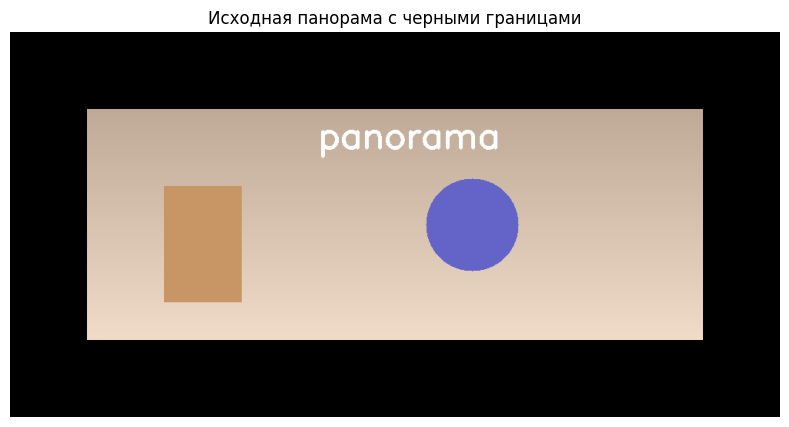

Найден максимальный прямоугольник:
  Координаты: (100, 100)
  Размер: 800x300
  Площадь: 240000 пикселей
  Исходный размер: 1000x500
  Сохранено: 48.0% площади


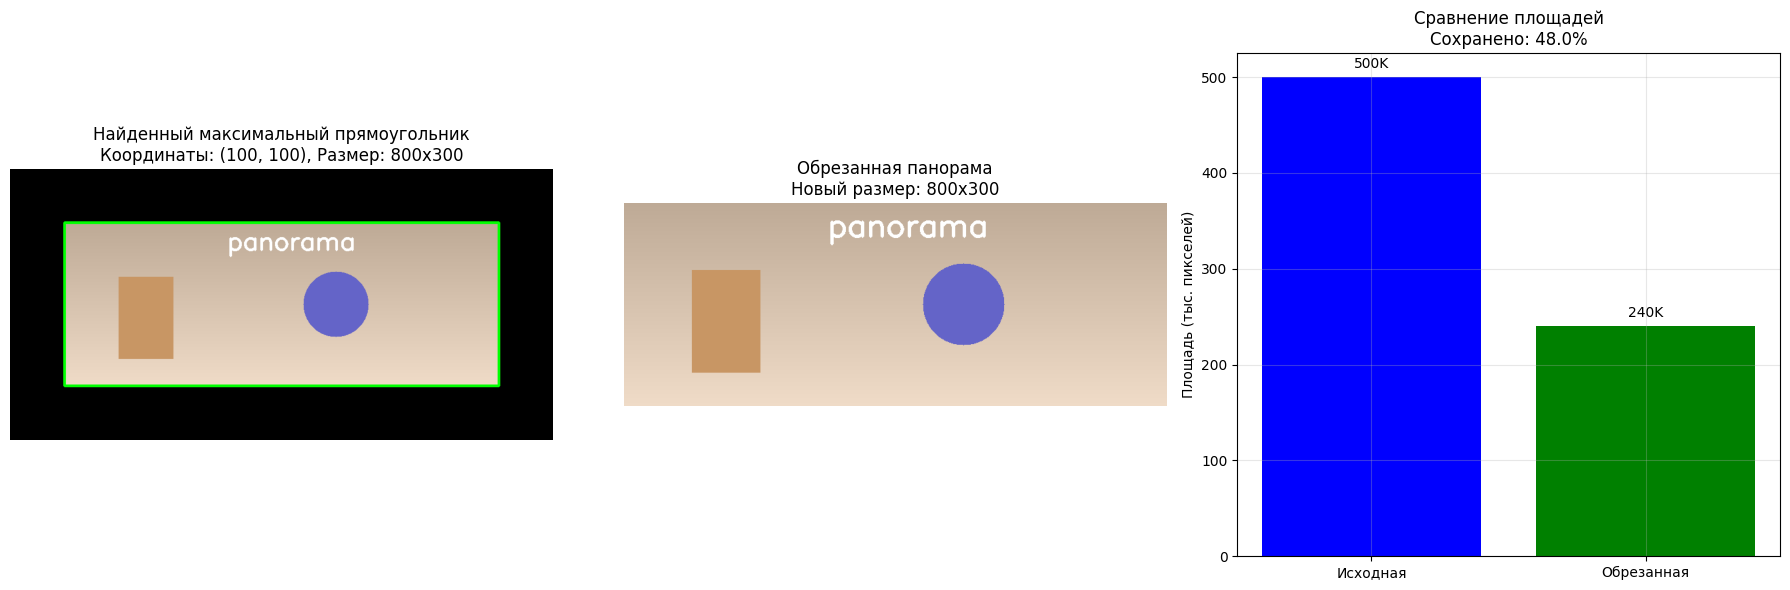


Применение алгоритма к 360° панораме:
Найден максимальный прямоугольник:
  Координаты: (3, 16)
  Размер: 735x399
  Площадь: 293265 пикселей
  Исходный размер: 752x452
  Сохранено: 86.3% площади


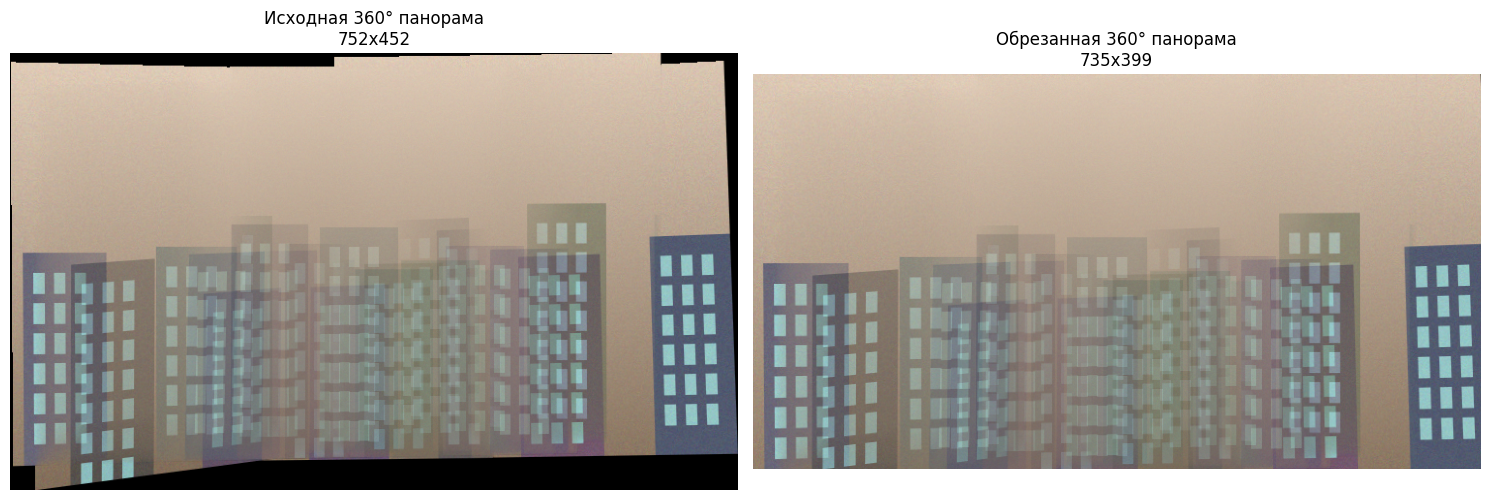

In [24]:
# ============================================
# 2. АВТОМАТИЧЕСКАЯ ОБРЕЗКА С МИНИМИЗАЦИЕЙ ПОТЕРЬ
# ============================================

def find_largest_rectangle_without_black(image, threshold=10):

    # Конвертируем в grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Создаем бинарную маску: 1 для нечерных пикселей, 0 для черных
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

    # Находим контуры
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return image, (0, 0, image.shape[1], image.shape[0])

    # Находим наибольший контур
    largest_contour = max(contours, key=cv2.contourArea)

    # Метод 1: Простой ограничивающий прямоугольник
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Метод 2: Ищем максимальный вписанный прямоугольник
    # Используем подход поиска максимальной площади
    height, width = mask.shape

    # Создаем гистограмму ненулевых пикселей по столбцам
    col_hist = np.sum(mask > 0, axis=0)

    # Создаем гистограмму ненулевых пикселей по строкам
    row_hist = np.sum(mask > 0, axis=1)

    # Находим границы по гистограммам
    left = 0
    while left < width and col_hist[left] == 0:
        left += 1

    right = width - 1
    while right >= 0 and col_hist[right] == 0:
        right -= 1

    top = 0
    while top < height and row_hist[top] == 0:
        top += 1

    bottom = height - 1
    while bottom >= 0 and row_hist[bottom] == 0:
        bottom -= 1

    # Вычисляем размеры
    w_hist = right - left + 1 if right >= left else 0
    h_hist = bottom - top + 1 if bottom >= top else 0

    # Выбираем лучший прямоугольник (по площади)
    area_bbox = w * h
    area_hist = w_hist * h_hist

    if area_hist > area_bbox:
        x, y, w, h = left, top, w_hist, h_hist

    # Метод 3: Оптимизированный поиск максимального прямоугольника
    # Используем алгоритм максимального прямоугольника в бинарной матрице
    def max_rectangle_in_histogram(hist):
        stack = []
        max_area = 0
        max_params = (0, 0, 0)

        for i in range(len(hist)):
            while stack and hist[stack[-1]] > hist[i]:
                height_idx = hist[stack.pop()]
                width = i if not stack else i - stack[-1] - 1
                area = height_idx * width
                if area > max_area:
                    max_area = area
                    max_params = (height_idx, width, i - width)

            stack.append(i)

        while stack:
            height_idx = hist[stack.pop()]
            width = len(hist) if not stack else len(hist) - stack[-1] - 1
            area = height_idx * width
            if area > max_area:
                max_area = area
                max_params = (height_idx, width, len(hist) - width)

        return max_area, max_params

    # Применяем алгоритм для каждой строки
    max_area_total = 0
    best_rect = (x, y, w, h)

    # Создаем матрицу высот
    heights = np.zeros((height, width), dtype=int)

    for i in range(height):
        for j in range(width):
            if mask[i, j] > 0:
                heights[i, j] = heights[i-1, j] + 1 if i > 0 else 1

    # Ищем максимальный прямоугольник
    for i in range(height):
        area, params = max_rectangle_in_histogram(heights[i])
        if area > max_area_total:
            max_area_total = area
            h_rect, w_rect, x_rect = params
            y_rect = i - h_rect + 1
            best_rect = (x_rect, y_rect, w_rect, h_rect)

    # Используем лучший найденный прямоугольник
    x, y, w, h = best_rect

    # Обрезаем изображение
    cropped = image[y:y+h, x:x+w]

    print(f"Найден максимальный прямоугольник:")
    print(f"  Координаты: ({x}, {y})")
    print(f"  Размер: {w}x{h}")
    print(f"  Площадь: {w*h} пикселей")
    print(f"  Исходный размер: {image.shape[1]}x{image.shape[0]}")
    print(f"  Сохранено: {w*h/(image.shape[1]*image.shape[0])*100:.1f}% площади")

    return cropped, (x, y, w, h)

def test_auto_cropping():
    """
    Тестирование автоматической обрезки панорамы.
    """
    print("\n" + "="*60)
    print("2. АВТОМАТИЧЕСКАЯ ОБРЕЗКА С МИНИМИЗАЦИЕЙ ПОТЕРЬ")
    print("="*60)

    # Используем созданную ранее панораму или создаем новую с черными границами
    # Создаем тестовую панораму с черными границами
    test_panorama = np.zeros((500, 1000, 3), dtype=np.uint8)

    # Добавляем контент в центре
    content_height, content_width = 300, 800
    start_y = (500 - content_height) // 2
    start_x = (1000 - content_width) // 2

    # Создаем градиентный фон для контента
    for y in range(content_height):
        for x in range(content_width):
            intensity = 150 + (y / content_height) * 50
            test_panorama[start_y + y, start_x + x] = [intensity, intensity + 20, intensity + 40]

    # Добавляем объекты
    cv2.rectangle(test_panorama, (start_x + 100, start_y + 100),
                 (start_x + 200, start_y + 250), (100, 150, 200), -1)
    cv2.circle(test_panorama, (start_x + 500, start_y + 150), 60, (200, 100, 100), -1)
    cv2.putText(test_panorama, 'panorama', (start_x + 300, start_y + 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 3)

    print("Тестовая панорама с черными границами создана")
    print(f"Исходный размер: {test_panorama.shape[1]}x{test_panorama.shape[0]}")
    print(f"Размер контента: {content_width}x{content_height}")

    # Визуализируем исходную панораму
    plt.figure(figsize=(15, 5))
    plt.imshow(cv2.cvtColor(test_panorama, cv2.COLOR_BGR2RGB))
    plt.title('Исходная панорама с черными границами')
    plt.axis('off')
    plt.show()

    # Применяем автоматическую обрезку
    cropped, rect = find_largest_rectangle_without_black(test_panorama, threshold=20)

    # Визуализируем процесс обрезки
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Исходное изображение с прямоугольником
    img_with_rect = test_panorama.copy()
    x, y, w, h = rect
    cv2.rectangle(img_with_rect, (x, y), (x+w, y+h), (0, 255, 0), 3)

    axes[0].imshow(cv2.cvtColor(img_with_rect, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Найденный максимальный прямоугольник\nКоординаты: ({x}, {y}), Размер: {w}x{h}')
    axes[0].axis('off')

    # Обрезанное изображение
    axes[1].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Обрезанная панорама\nНовый размер: {cropped.shape[1]}x{cropped.shape[0]}')
    axes[1].axis('off')

    # Сравнение площадей
    original_area = test_panorama.shape[1] * test_panorama.shape[0]
    cropped_area = cropped.shape[1] * cropped.shape[0]
    preserved_percentage = cropped_area / original_area * 100

    axes[2].bar(['Исходная', 'Обрезанная'], [original_area/1000, cropped_area/1000], color=['blue', 'green'])
    axes[2].set_ylabel('Площадь (тыс. пикселей)')
    axes[2].set_title(f'Сравнение площадей\nСохранено: {preserved_percentage:.1f}%')
    axes[2].grid(True, alpha=0.3)

    # Добавляем значения на столбцы
    for i, v in enumerate([original_area/1000, cropped_area/1000]):
        axes[2].text(i, v + 10, f'{v:.0f}K', ha='center')

    plt.tight_layout()
    plt.show()

    # Тестирование на реальной панораме (если она есть)
    if 'panorama_360_result' in globals():
        print("\nПрименение алгоритма к 360° панораме:")
        panorama_cropped, panorama_rect = find_largest_rectangle_without_black(panorama_360_result)

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        axes[0].imshow(cv2.cvtColor(panorama_360_result, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f'Исходная 360° панорама\n{panorama_360_result.shape[1]}x{panorama_360_result.shape[0]}')
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(panorama_cropped, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'Обрезанная 360° панорама\n{panorama_cropped.shape[1]}x{panorama_cropped.shape[0]}')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    return cropped, rect

# Запускаем тест автоматической обрезки
cropping_result = test_auto_cropping()


3. ВЕРТИКАЛЬНАЯ ПАНОРАМА

Создание синтетических изображений для вертикальной панорамы...
Создано 4 изображений для вертикальной панорамы


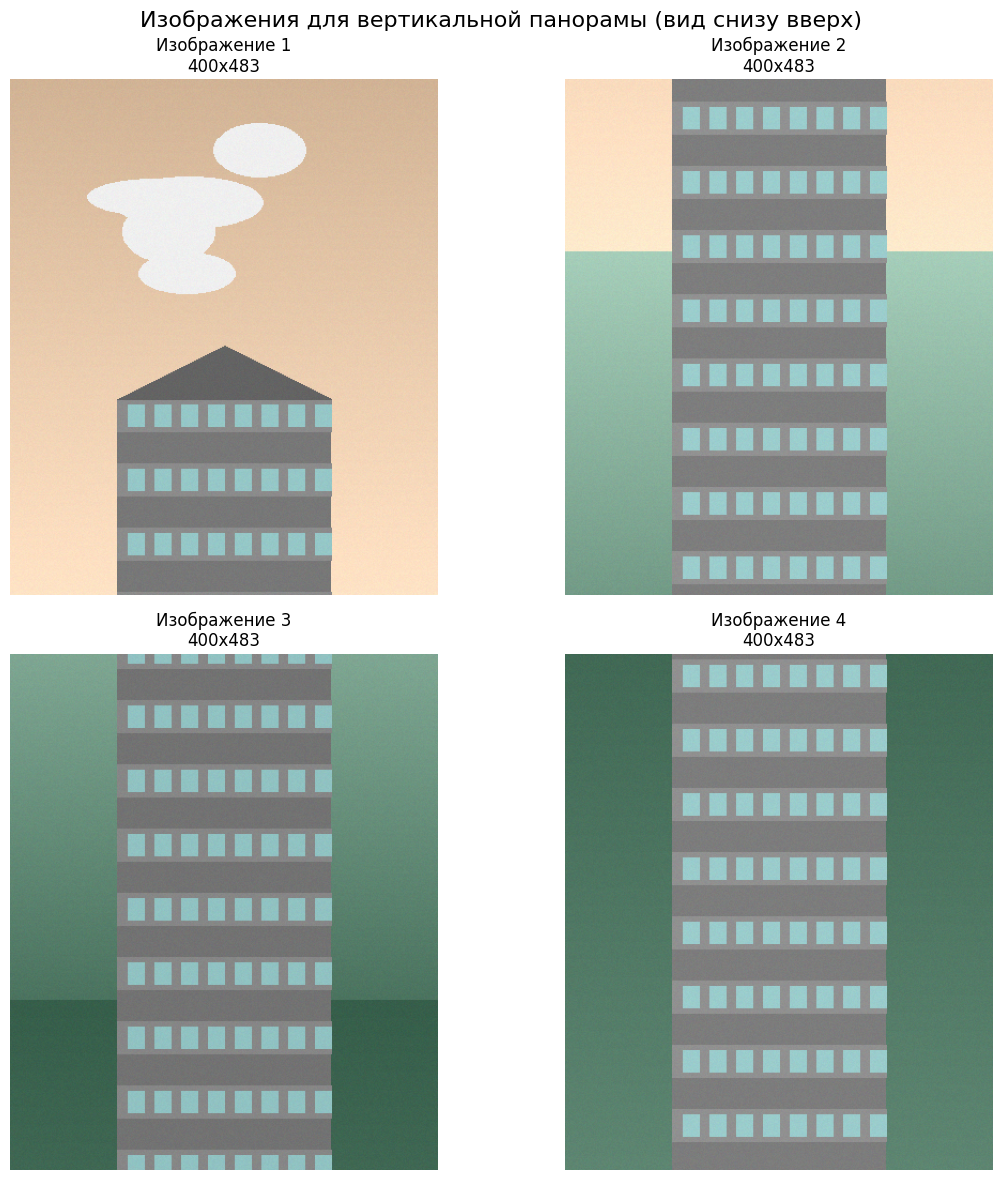

Сшивание вертикальной панорамы...
Используем SIFT детектор для вертикальной панорамы
Изображение 1: 128 ключевых точек
Изображение 2: 261 ключевых точек
Изображение 3: 227 ключевых точек
Изображение 4: 227 ключевых точек
Соответствий между изображениями 1 и 2: 36
Соответствий между изображениями 2 и 3: 42
Соответствий между изображениями 3 и 4: 34
Размер вертикальной панорамы: 1043x493
Соотношение сторон: 0.47:1


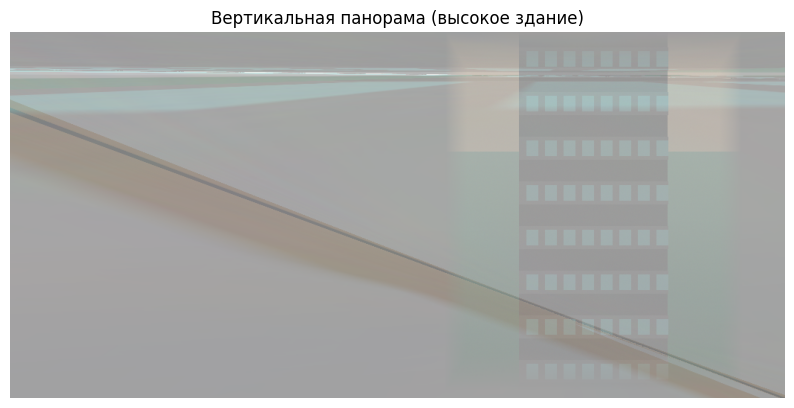

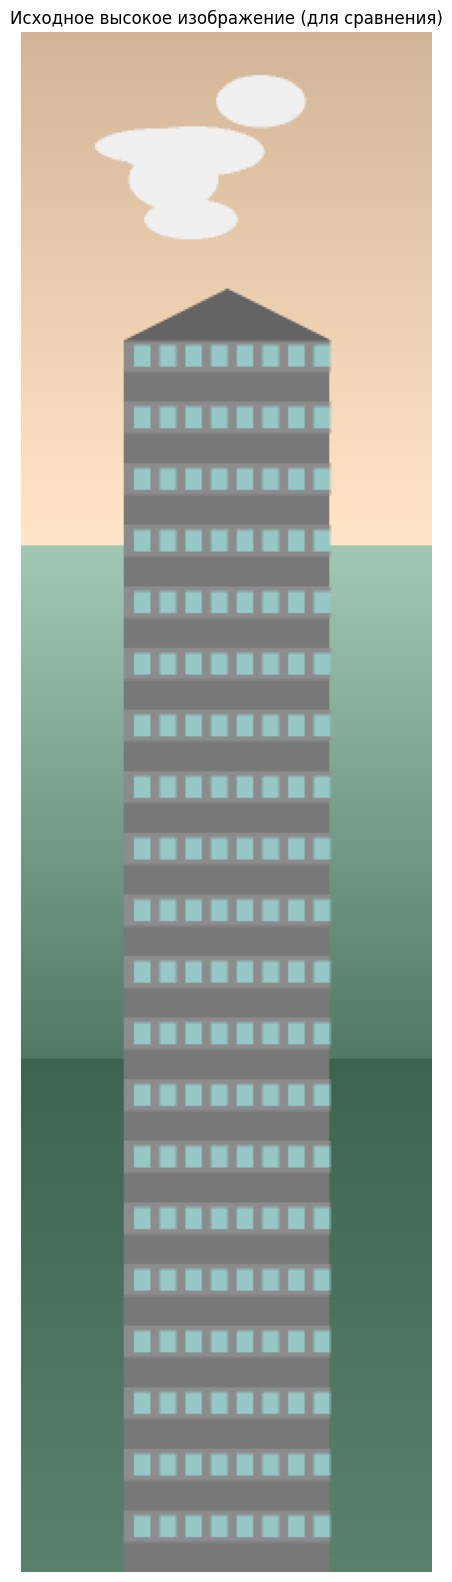


Анализ вертикальной панорамы:
Размер исходных изображений: 400x483
Количество изображений: 4
Общая высота без перекрытия: 1932
Высота панорамы: 493
Увеличение высоты: 1.02x


In [32]:
# ============================================
# 3. ВЕРТИКАЛЬНАЯ ПАНОРАМА
# ============================================

def create_vertical_panorama_images_simple():
    print("\nСоздание синтетических изображений для вертикальной панорамы...")

    # Базовое вертикальное изображение (высокое здание)
    base_width = 400
    base_height = 1200  # Уменьшаем для быстрой обработки

    # Создаем базовое изображение
    base = np.zeros((base_height, base_width, 3), dtype=np.uint8)

    # Верхняя часть - небо (градиент от светлого к темному синему)
    sky_height = base_height // 3
    for y in range(sky_height):
        intensity = int(200 - y * 0.3)  # От 200 до ~160
        base[y, :] = [intensity, intensity + 30, intensity + 60]

    # Средняя часть - здание
    building_start = sky_height
    building_height = base_height - sky_height

    # Рисуем здание
    building_width = 200
    building_x = (base_width - building_width) // 2

    # Основное здание
    cv2.rectangle(base, (building_x, building_start),
                 (building_x + building_width, base_height),
                 (120, 120, 120), -1)

    # Добавляем окна
    window_size = 15
    window_spacing = 25

    for floor in range(15):
        floor_y = building_start + floor * 40 + 10
        for col in range(8):
            window_x = building_x + 10 + col * window_spacing
            cv2.rectangle(base, (window_x, floor_y),
                         (window_x + window_size, floor_y + 20),
                         (200, 200, 100), -1)

    # Крыша
    roof_points = np.array([
        [building_x, building_start],
        [building_x + building_width, building_start],
        [building_x + building_width // 2, building_start - 30]
    ], np.int32)
    cv2.fillPoly(base, [roof_points], (100, 100, 100))

    # Облака
    for i in range(3):
        cloud_x = np.random.randint(50, base_width - 100)
        cloud_y = np.random.randint(50, 150)
        cloud_w = np.random.randint(60, 120)
        cloud_h = np.random.randint(20, 40)
        cv2.ellipse(base, (cloud_x, cloud_y), (cloud_w//2, cloud_h//2),
                   0, 0, 360, (220, 220, 220), -1)

    # Создаем 3 перекрывающихся вертикальных изображения
    images_vertical = []
    num_images = 3
    overlap = 0.25  # 25% перекрытия

    segment_height = int(base_height / (num_images * (1 - overlap) + overlap))

    for i in range(num_images):
        start_y = int(i * segment_height * (1 - overlap))
        end_y = min(start_y + segment_height, base_height)

        segment = base[start_y:end_y, :].copy()

        # Добавляем небольшие вариации
        brightness = np.random.randint(-5, 5)
        segment = cv2.add(segment, brightness)

        images_vertical.append(segment)

    print(f"Создано {len(images_vertical)} изображений для вертикальной панорамы")
    return images_vertical, base

def stitch_vertical_panorama(images):
    """
    Сшивает изображения в вертикальную панораму.
    Адаптация алгоритма сшивки для вертикальной ориентации.
    """
    print("Сшивание вертикальной панорамы...")

    # Инициализируем детектор
    try:
        detector = cv2.SIFT_create()
        print("Используем SIFT детектор для вертикальной панорамы")
    except:
        detector = cv2.ORB_create(nfeatures=2000)
        print("Используем ORB детектор для вертикальной панорамы")

    # Детектируем ключевые точки и дескрипторы
    keypoints_list = []
    descriptors_list = []

    for i, img in enumerate(images):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        kp, des = detector.detectAndCompute(gray, None)
        keypoints_list.append(kp)
        descriptors_list.append(des)
        print(f"Изображение {i+1}: {len(kp)} ключевых точек")

    # Сопоставляем изображения (вертикальное перекрытие)
    homographies = []

    for i in range(len(images) - 1):
        # Сопоставляем дескрипторы
        if descriptors_list[i].dtype == np.float32:
            matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
        else:
            matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

        matches = matcher.knnMatch(descriptors_list[i], descriptors_list[i+1], k=2)

        # Применяем тест отношения Лоу
        good_matches = []
        for m_n in matches:
            if len(m_n) == 2:
                m, n = m_n
                if m.distance < 0.75 * n.distance:
                    good_matches.append(m)

        print(f"Соответствий между изображениями {i+1} и {i+2}: {len(good_matches)}")

        # Вычисляем гомографию
        if len(good_matches) >= 4:
            src_pts = np.float32([keypoints_list[i][m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst_pts = np.float32([keypoints_list[i+1][m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

            H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
            homographies.append(H)
        else:
            homographies.append(None)

    # Для вертикальной панорамы используем второе изображение как базовое
    base_idx = 1

    # Вычисляем составные гомографии
    cumulative_H = [None] * len(images)
    cumulative_H[base_idx] = np.eye(3)

    # Для изображений выше базового
    for i in range(base_idx + 1, len(images)):
        if cumulative_H[i-1] is not None and homographies[i-1] is not None:
            cumulative_H[i] = cumulative_H[i-1] @ homographies[i-1]

    # Для изображений ниже базового
    for i in range(base_idx - 1, -1, -1):
        if cumulative_H[i+1] is not None and homographies[i] is not None:
            H_inv = np.linalg.inv(homographies[i])
            cumulative_H[i] = cumulative_H[i+1] @ H_inv

    # Находим границы вертикальной панорамы
    corners_all = []

    for i, img in enumerate(images):
        if cumulative_H[i] is None:
            continue

        h, w = img.shape[:2]
        corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
        corners_transformed = cv2.perspectiveTransform(corners, cumulative_H[i])
        corners_all.append(corners_transformed)

    corners_all = np.concatenate(corners_all, axis=0)
    [x_min, y_min] = np.int32(corners_all.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(corners_all.max(axis=0).ravel() + 0.5)

    translation_dist = [-x_min, -y_min]
    H_translation = np.array([[1, 0, translation_dist[0]],
                              [0, 1, translation_dist[1]],
                              [0, 0, 1]])

    output_width = x_max - x_min
    output_height = y_max - y_min

    # Создаем вертикальную панораму с alpha blending
    panorama = np.zeros((output_height, output_width, 3), dtype=np.float32)
    weights = np.zeros((output_height, output_width), dtype=np.float32)

    for i, img in enumerate(images):
        if cumulative_H[i] is None:
            continue

        H_adjusted = H_translation @ cumulative_H[i]
        img_warped = cv2.warpPerspective(img, H_adjusted, (output_width, output_height))

        # Создаем маску весов (расстояние до границы)
        h_img, w_img = img.shape[:2]
        mask = np.ones((h_img, w_img), dtype=np.float32)

        # Растушёвка по краям (особенно по вертикальным)
        feather_width = 30
        feather_height = 50  # Большее растушёвывание по вертикали для плавного перехода

        for y in range(h_img):
            for x in range(w_img):
                dist_to_left = x
                dist_to_right = w_img - x - 1
                dist_to_top = y
                dist_to_bottom = h_img - y - 1

                # Вертикальные края важнее для вертикальной панорамы
                horizontal_feather = min(dist_to_left, dist_to_right) / feather_width
                vertical_feather = min(dist_to_top, dist_to_bottom) / feather_height

                mask[y, x] = min(horizontal_feather, vertical_feather, 1.0)

        mask_warped = cv2.warpPerspective(mask, H_adjusted, (output_width, output_height))

        # Накапливаем изображение и веса
        for c in range(3):
            panorama[:, :, c] += img_warped[:, :, c] * mask_warped
        weights += mask_warped

    # Нормализуем по весам
    for c in range(3):
        panorama[:, :, c] = np.divide(
            panorama[:, :, c],
            weights,
            out=np.zeros_like(panorama[:, :, c]),
            where=weights!=0
        )

    panorama = np.clip(panorama, 0, 255).astype(np.uint8)

    print(f"Размер вертикальной панорамы: {output_width}x{output_height}")
    print(f"Соотношение сторон: {output_height/output_width:.2f}:1")

    return panorama

def test_vertical_panorama():
    """
    Тестирование создания вертикальной панорамы.
    """
    print("\n" + "="*60)
    print("3. ВЕРТИКАЛЬНАЯ ПАНОРАМА")
    print("="*60)

    # Создаем изображения для вертикальной панорамы
    images_vertical, base_image = create_vertical_panorama_images()

    # Визуализируем исходные изображения
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))

    for i, img in enumerate(images_vertical):
        ax = axes[i // 2, i % 2]
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Изображение {i+1}\n{img.shape[1]}x{img.shape[0]}')
        ax.axis('off')

    plt.suptitle('Изображения для вертикальной панорамы (вид снизу вверх)', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Создаем вертикальную панораму
    panorama_vertical = stitch_vertical_panorama(images_vertical)

    # Визуализируем результат
    plt.figure(figsize=(10, 20))
    plt.imshow(cv2.cvtColor(panorama_vertical, cv2.COLOR_BGR2RGB))
    plt.title('Вертикальная панорама (высокое здание)')
    plt.axis('off')
    plt.show()

    # Показываем базовое изображение для сравнения
    plt.figure(figsize=(10, 20))
    plt.imshow(cv2.cvtColor(base_image, cv2.COLOR_BGR2RGB))
    plt.title('Исходное высокое изображение (для сравнения)')
    plt.axis('off')
    plt.show()

    # Анализ результатов
    print("\nАнализ вертикальной панорамы:")
    print(f"Размер исходных изображений: {images_vertical[0].shape[1]}x{images_vertical[0].shape[0]}")
    print(f"Количество изображений: {len(images_vertical)}")
    print(f"Общая высота без перекрытия: {images_vertical[0].shape[0] * len(images_vertical)}")
    print(f"Высота панорамы: {panorama_vertical.shape[0]}")
    print(f"Увеличение высоты: {panorama_vertical.shape[0]/(images_vertical[0].shape[0]):.2f}x")

    return panorama_vertical

# Запускаем тест вертикальной панорамы
vertical_panorama_result = test_vertical_panorama()